RNN - Erro dos pesos computados e usado somente durante a iteração

In [121]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import matplotlib.cm as cm
import optuna
from optuna.samplers import RandomSampler
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.exceptions import TrialPruned
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
#from Testing.RTLO import *
from Functions.RLS import *
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
FileName = ipynbname.name()

df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def prepare_data(sig, n, m):
    X, Y = [], []
    # O shift (s) é calculado para alinhar o final de Y com a predição futura
    # Seguindo sua lógica: se n=4, m=3 -> Y começa no índice 2 (hi_3)
    s = n - m + 1 
    
    for i in range(len(sig) - n - 1):
        X.append(sig[i : i + n])
        Y.append(sig[i + s : i + s + m])
        
    return np.array(X), np.array(Y)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def Act(x):
    return np.tanh(x)

def dAct(x):
    return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow


class RNN:

    def __init__(self, n_in, n_rec, n_out, h0, tau_m=10):
        np.random.seed(42)
        self.n_in = n_in
        self.n_rec = n_rec
        self.n_out = n_out
        self.hi = np.zeros(n_rec)
        self.hf = np.zeros(n_rec)
        self.h0 = h0
        self.tau_m = tau_m

        # Initialize weights:
        self.w_in = 0.1*(np.random.rand(n_rec, n_in) - 1)
        self.w_rec = 1.5*np.random.randn(n_rec, n_rec)/n_rec**0.5
        self.w_out = 0.1*(2*np.random.rand(n_out, n_rec) - 1)/n_rec**0.5

        # Random error feedback matrix:
        self.b = np.random.randn(n_rec, n_out)/n_out**0.5
        self.k = 1


    def run_trial(self, x, y_, eta=[0.1, 0.1, 0.1]):

        k = 1
        [eta3, eta2, eta1] = eta  # learning rates for w_in, w_rec, and w_out
        t_max = np.shape(x)[0]  # number of timesteps
        dw_in, dw_rec, dw_out = 0, 0, 0  # changes to weights
        dw_in2, dw_rec2, dw_out2 = 0, 0, 0  # changes to weights

        u = np.zeros((t_max, self.n_rec))  # input (feedforward plus recurrent)
        h = np.zeros((t_max, self.n_rec))  # time-dependent RNN activity vector
        h[0] = self.h0  # initial state
        y = np.zeros((t_max, self.n_out))  # RNN output
        err = np.zeros((t_max, self.n_out))  # readout error

        p = np.zeros((self.n_rec, self.n_rec))
        q = np.zeros((self.n_rec, self.n_in))

        for jj in range(self.n_rec):
            q[jj, :] = dAct(u[0, jj])*x[0,:]/self.tau_m

        for tt in range(t_max-1):
            u[tt+1] = np.dot(self.w_rec, h[tt]) + np.dot(self.w_in, x[tt+1])
            h[tt+1] = h[tt] + (-h[tt] + Act(u[tt+1]))/self.tau_m
            y[tt+1] = np.dot(self.w_out, h[tt+1])
            err[tt+1] = y_[tt+1] - y[tt+1]  # readout error
            #print('real:',y_[tt+1])
            #print('pred:',y[tt+1])

            p = (1-1/self.tau_m)*p
            q = (1-1/self.tau_m)*q
            p += np.outer(dAct(u[tt+1,:]), h[tt,:])/self.tau_m
            q += np.outer(dAct(u[tt+1,:]), x[tt,:])/self.tau_m


            dw_out = eta1 * np.outer(err[tt+1], h[tt+1])/t_max
            dw_rec = eta2 * np.outer(np.dot(self.b, err[tt+1]),
                                    np.ones(self.n_rec))*p/t_max
            dw_in = eta3 * np.outer(np.dot(self.b, err[tt+1]),
                                    np.ones(self.n_in))*q/t_max
            
            dw_out2 =  (((k-1)*dw_out2/k) + (eta1 *np.outer(err[tt+1], h[tt+1])/k))
            dw_rec2 =  (((k-1)*dw_rec2/k) + (eta2 *np.outer(np.dot(self.b, err[tt+1]),np.ones(self.n_rec))*p/k))
            dw_in2 =  (((k-1)*dw_in2/k) + (eta3 *np.outer(np.dot(self.b, err[tt+1]),np.ones(self.n_in))*q/k))

            self.w_out = self.w_out +  dw_out
            self.w_rec = self.w_rec +  dw_rec
            self.w_in = self.w_in +  dw_in
            k = k + 1

        return y, h, u
    
    def PredSingle(self,x):
        u = np.dot(self.w_rec, self.hi) + np.dot(self.w_in, x)
        hf = self.hi + (-self.hi + Act(u))/self.tau_m
        y = np.dot(self.w_out, hf)
        self.hi = hf
        return y
    
    def run_session(self, n_trials, x, y_, eta=[0.1, 0.1, 0.1]):

        t_max = np.shape(x)[0]  # number of timesteps
        loss_list = []
        readout_alignment = []

        # Flatten the random feedback matrix to check for feedback alignment:
        bT_flat = np.reshape((self.b).T,
            (np.shape(self.b)[0]*np.shape(self.b)[1]))
        bT_flat = bT_flat/np.linalg.norm(bT_flat)

        for ii in range(n_trials):
            y, h, u = self.run_trial(x, y_, eta)

            err = y_ - y
            loss = 0.5*np.mean(err**2)
            loss_list.append(loss)

            w_out_flat = np.reshape(self.w_out,
                (np.shape(self.w_out)[0]*np.shape(self.w_out)[1]))
            w_out_flat = w_out_flat/np.linalg.norm(w_out_flat)
            readout_alignment.append(np.dot(bT_flat, w_out_flat))
            print('\r'+str(ii+1)+'/'+str(n_trials)+'\t Err:'+str(loss), end='')

        return y, loss_list, readout_alignment

In [400]:
n_in, n_rec, n_out = 10, 10, 10  # number of inputs, recurrent units, and outputs

X, yR = prepare_data(sig,n_in,n_out)

n_tr = 5000  # number of trials to train on 

h_init = 0.1*np.ones(n_rec)  # initial state of the RNN

print('\nTraining with BPTT...')
rnn = RNN(n_in, n_rec, n_out, h_init)
#print(rnn.w_rec)
learn_rates = [0.001, 0.001, 0.001]
yP, loss_list1, _ = rnn.run_session(n_tr, X, yR, eta=learn_rates)
#print(rnn.w_in.T[0][:5])



Training with BPTT...
5000/5000	 Err:0.0045667270089422594

In [401]:
yP_ = []
for x in X:
    yP = rnn.PredSingle(x)
    yP_.append(yP)
yP = np.array(yP_)[:,-1]

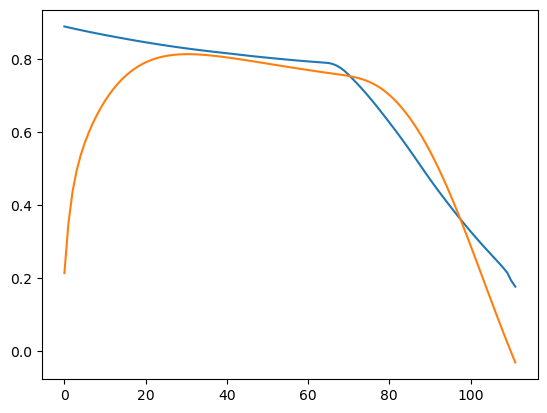

In [402]:
plt.plot(yR[:,-1])
plt.plot(yP)

In [385]:
yP_

[array([0.24798946, 0.24719223, 0.24632967, 0.2457217 ]),
 array([0.45699333, 0.45555191, 0.4539876 , 0.45283632]),
 array([0.62759213, 0.62565288, 0.62354388, 0.62192745]),
 array([0.76152902, 0.75922711, 0.75672127, 0.75472696]),
 array([0.86209224, 0.85954649, 0.85677592, 0.85449247]),
 array([0.93386944, 0.93117857, 0.92825438, 0.92576435]),
 array([0.9820668 , 0.97930824, 0.97631837, 0.97369287]),
 array([1.01179287, 1.00902402, 1.00603409, 1.00333071]),
 array([1.02757265, 1.0248337 , 1.02188988, 1.01915299]),
 array([1.03314025, 1.03045753, 1.02759018, 1.02485254]),
 array([1.03143411, 1.02882328, 1.02605053, 1.02333544]),
 array([1.02469347, 1.0221623 , 1.01949317, 1.01681642]),
 array([1.01458868, 1.01213922, 1.00957612, 1.00694777]),
 array([1.00234772, 0.99997799, 0.99751866, 0.99494441]),
 array([0.98886263, 0.98656792, 0.98420689, 0.9816892 ]),
 array([0.97477454, 0.97254832, 0.97027799, 0.9678169 ]),
 array([0.96053893, 0.95837357, 0.95618502, 0.9537788 ]),
 array([0.9464

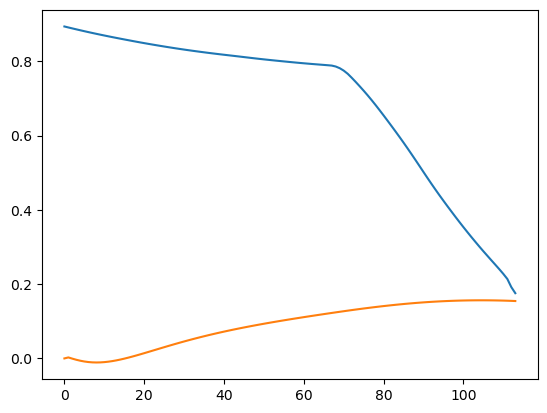

In [311]:
plt.plot(yR[:,-1])
plt.plot(yP[:,-1])